# Phase 4 — Baseline Models

Goal:
Compare non-graph and spatial baselines before Phase 5 GNN.

Models:
1. Naive Mean
2. Ridge Regression
3. Random Forest
4. XGBoost
5. CNN Spatial Baseline

Scientific purpose:
- RF/XGBoost: tabular, no graph topology
- CNN: local spatial context, no graph topology
- GNN: graph topology + message passing

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()

metrics_path = PROJECT_ROOT / "reports" / "tables" / "phase4_baseline_metrics.csv"
binned_path = PROJECT_ROOT / "reports" / "tables" / "phase4_binned_metrics.csv"
importance_path = PROJECT_ROOT / "reports" / "tables" / "phase4_feature_importances.csv"

metrics = pd.read_csv(metrics_path)
binned = pd.read_csv(binned_path)
importance = pd.read_csv(importance_path)

metrics

,model,r2,mae,spearman,brier,ece,n_test,fit_predict_seconds
0,Naive Mean,-0.295611,0.024118,0.000000,0.001808,0.020310,57531,0.02
1,Ridge Regression,0.136255,0.018808,0.801188,0.001205,0.012206,57531,0.42
2,Random Forest,0.661701,0.012503,0.892628,0.000472,0.005945,57531,67.09
3,XGBoost,0.676144,0.012589,0.887281,0.000452,0.005018,57531,11.44


In [2]:
metrics.sort_values("r2", ascending=False)

,model,r2,mae,spearman,brier,ece,n_test,fit_predict_seconds
3,XGBoost,0.676144,0.012589,0.887281,0.000452,0.005018,57531,11.44
2,Random Forest,0.661701,0.012503,0.892628,0.000472,0.005945,57531,67.09
1,Ridge Regression,0.136255,0.018808,0.801188,0.001205,0.012206,57531,0.42
0,Naive Mean,-0.295611,0.024118,0.000000,0.001808,0.020310,57531,0.02


In [3]:
metrics.sort_values("mae", ascending=True)

,model,r2,mae,spearman,brier,ece,n_test,fit_predict_seconds
2,Random Forest,0.661701,0.012503,0.892628,0.000472,0.005945,57531,67.09
3,XGBoost,0.676144,0.012589,0.887281,0.000452,0.005018,57531,11.44
1,Ridge Regression,0.136255,0.018808,0.801188,0.001205,0.012206,57531,0.42
0,Naive Mean,-0.295611,0.024118,0.000000,0.001808,0.020310,57531,0.02


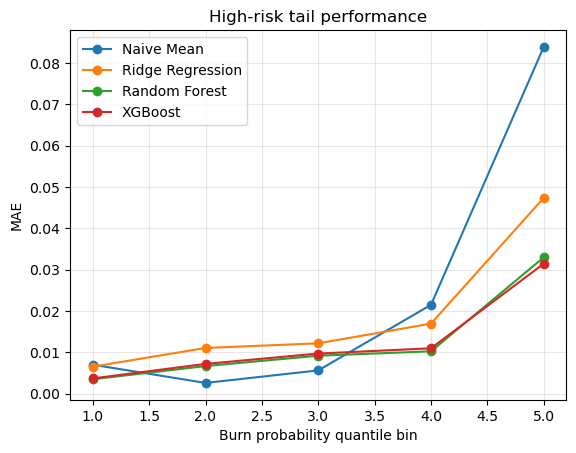

In [4]:
for model in binned["model"].unique():
    df = binned[binned["model"] == model].sort_values("bin")
    plt.plot(df["bin"], df["mae"], marker="o", label=model)

plt.xlabel("Burn probability quantile bin")
plt.ylabel("MAE")
plt.title("High-risk tail performance")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [5]:
importance.head(30)

,model,rank,feature,importance
0,Random Forest,1,FSP_Index_mean_3x3,0.126332
1,Random Forest,2,FSP_Index_mean_15x15,0.115469
2,Random Forest,3,FSP_Index,0.099163
3,Random Forest,4,FSP_Index_mean_7x7,0.099112
4,Random Forest,5,Struct_Exp_Index,0.093662
5,Random Forest,6,Ignition_Prob_mean_15x15,0.039759
6,Random Forest,7,interact_Ignition_FSP,0.038110
7,Random Forest,8,FSP_Index_std_7x7,0.033055
8,Random Forest,9,FSP_Index_std_15x15,0.030597
9,Random Forest,10,CFL_mean_15x15,0.029406
